In [65]:
import osmium
import osmium.filter
import osmium.osm
import pandana

In [ ]:
# https://docs.osmcode.org/pyosmium/latest/user_manual/04-Working-with-Filters/

data= "../../denmark-260208.osm.pbf"
fp = osmium.FileProcessor(data).with_locations().with_areas() \
    .with_filter(osmium.filter.TagFilter(
            ("amenity", "restaurant"), 
            ("amenity", "cafe"),
            ("amenity", "fast_food"),
    )
)

cnt = 0
for entity in fp:
    if cnt >= 3:
        break
    cnt += 1
    display(entity)

osmium.osm.Node(id=10477163, deleted=False, visible=True, version=14, changeset=0, uid=0, timestamp=datetime.datetime(2023, 10, 28, 23, 38, 50, tzinfo=datetime.timezone.utc), user='', tags=osmium.osm.TagList({'amenity': 'restaurant', 'cuisine': 'nordic;french', 'fvst:name': 'HENNE MØLLEÅ BADEHOTEL Sammenslutningen af frie Funktionærer', 'fvst:navnelbnr': '74632', 'name': 'Henne Mølle Å Badehotel', 'opening_hours': 'Jan-Feb Th-Sa 12:00-23:00, Su 12:00-17:00; Mar-May 12:00-23:00; Jun-Aug 12:00-23:00; Sep-Oct 12:00-23:00; Nov Mo-We 15:00-23:00,Th-Su 12:00-23:00', 'opening_hours:kitchen': 'Jan-Feb Th-Sa 12:00-19:00, Su 12:00-17:00; Mar-May 12:00-19:00; Jun-Aug 12:00-20:30; Sep-Oct 12:00-19:00; Nov Mo-We 15:00-19:00,Th-Su 12:00-19:00', 'phone': '+45 76524000', 'ref:DK:cvr': '56154515', 'ref:DK:cvr:pnummer': '1013636253', 'website': 'https://www.hennemoelleaa.dk/', 'wheelchair': 'limited'}), location=osmium.osm.Location(x=81712970, y=557205945))

osmium.osm.Node(id=24971137, deleted=False, visible=True, version=25, changeset=0, uid=0, timestamp=datetime.datetime(2025, 7, 22, 13, 11, 18, tzinfo=datetime.timezone.utc), user='', tags=osmium.osm.TagList({'amenity': 'restaurant', 'cuisine': 'indian', 'fvst:navnelbnr': '1483591', 'indoor_seating': 'yes', 'microbrewery': 'yes', 'name': 'Juma', 'old_name': 'Nørrebro Bryghus Restaurant', 'operator': 'Madklubben', 'outdoor_seating': 'yes', 'ref:DK:cvr': '33083351', 'ref:DK:cvr:pnummer': '1031033620', 'reservation': '+45 50488434', 'website': 'https://restaurantjuma.dk/', 'wheelchair': 'yes', 'wheelchair:description': 'Adgang via elevator gennem port. Ingen armstøtte ved toilet'}), location=osmium.osm.Location(x=125640201, y=556903480))

osmium.osm.Node(id=26727018, deleted=False, visible=True, version=5, changeset=0, uid=0, timestamp=datetime.datetime(2022, 1, 19, 16, 47, 8, tzinfo=datetime.timezone.utc), user='', tags=osmium.osm.TagList({'amenity': 'restaurant', 'cuisine': 'regional', 'fvst:navnelbnr': '108905', 'name': 'Vigen', 'opening_hours': 'Apr-Sep 12:00-22:00; Oct-Mar Mo-We 12:00-22:00', 'phone': '+45 46755008', 'ref:DK:cvr': '30498666', 'ref:DK:cvr:pnummer': '1013191790'}), location=osmium.osm.Location(x=120815339, y=556732754))

In [70]:
import pandas as pd

def to_row(obj):
    if obj.is_way():
        nodes = [n for n in obj.nodes if n.location.valid()]
        return {
            "x": sum(n.lon for n in nodes) / len(nodes),
            "y": sum(n.lat for n in nodes) / len(nodes),
            "value": 12345
        }
    
    return {
        "x": obj.location.lon,
        "y": obj.location.lat,
        "value": 12345
    }

df = pd.DataFrame.from_records([to_row(obj) for obj in fp])
display(df.head())
display(df.size)

AttributeError: 'Relation' object has no attribute 'location'

Generating contraction hierarchies with 24 threads.
Setting CH node vector of size 1215
Setting CH edge vector of size 1622
Range graph removed 42 edges of 3244
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
 100% 

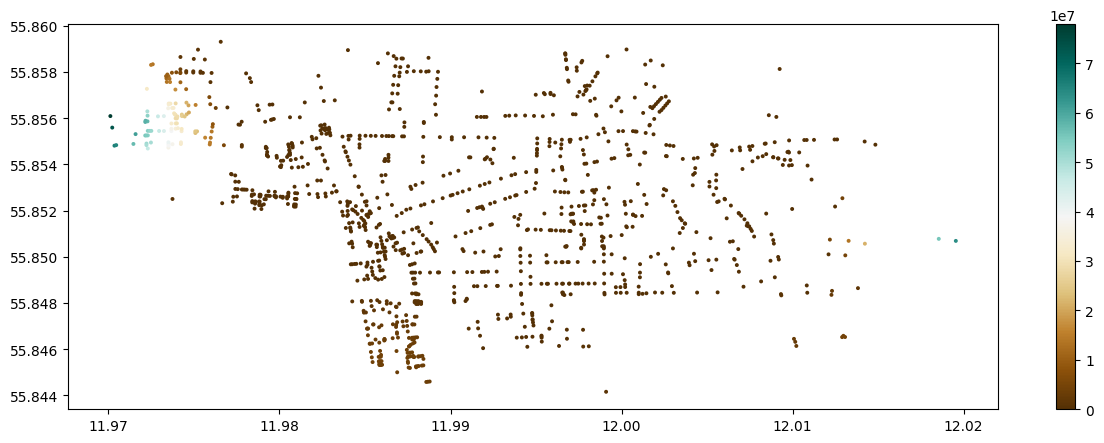

(<Figure size 1500x500 with 2 Axes>, <Axes: >)

In [ ]:
network = pandana.Network.from_hdf5("network.backup")
network.precompute(3000)

x, y = df.x,df.y
df["node_ids"] = network.get_node_ids(x, y)
network.set(df["node_ids"], variable=df.value, name="value")

aggregate = network.aggregate(500, type="sum", decay="linear", name="value")

bbox_jp = [55.845085, 11.970291, 55.858888, 12.014236]
network.plot(aggregate, bbox=bbox_jp,
         fig_kwargs={'figsize': [15, 5]},
         plot_kwargs={'cmap': 'BrBG', 's': 8, 'edgecolor': 'none'})